# Bildkompression mit Singulärwertzerlegung

In [24]:
import numpy as np
from PIL import Image
from matplotlib import pyplot as plt



## Bild-Upload

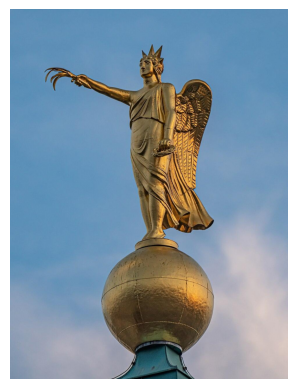

In [25]:

img = Image.open('./Friedensengel_100kB.jpg')

#Bildanzeige mit matplotlib
fig = plt.figure()
ax1 = fig.add_subplot(1,1,1)
ax1.imshow(img)
plt.axis('off')
plt.show()

## Umwandlung in Schwarzweiß-Bild

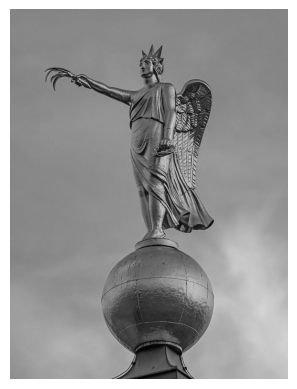

In [26]:
#Umwandlung in Grauwerte
img = img.convert('L')

#Bildanzeige mit matplotlib
fig = plt.figure()
ax1 = fig.add_subplot(1,1,1)
ax1.imshow(img,cmap='gray')
plt.axis('off')
plt.show()

In [27]:
A= np.array(img)


## Dimension des Bildes

In [28]:
[m,n]=A.shape
[m,n]

[1280, 960]

## Anzeige der links oberen 10x10 Werte der Bildmatrix

In [29]:
A[0:10,0:10]

array([[133, 133, 133, 133, 133, 133, 133, 133, 133, 132],
       [133, 133, 133, 133, 133, 133, 133, 133, 133, 132],
       [133, 133, 133, 133, 133, 133, 133, 133, 132, 132],
       [133, 133, 133, 133, 133, 133, 133, 133, 132, 132],
       [133, 133, 133, 133, 133, 133, 133, 133, 131, 131],
       [133, 133, 133, 133, 133, 133, 133, 133, 130, 131],
       [133, 133, 133, 133, 133, 133, 133, 133, 130, 131],
       [133, 133, 133, 133, 133, 133, 133, 133, 130, 131],
       [133, 133, 132, 132, 131, 131, 130, 130, 128, 129],
       [133, 132, 132, 132, 131, 131, 130, 130, 133, 132]], dtype=uint8)

## Singulärwertzerlegung

In [30]:
# Vh ist die Transponierte von V
U,S,Vh=np.linalg.svd(A, full_matrices=True)


In [31]:
U.shape

(1280, 1280)

In [32]:
S.shape

(960,)

In [33]:
Vh.shape

(960, 960)

## Anzahl genutzter Singulärwerte

In [34]:
# Anzahl verwendeter Singulärwerte
k=50


# Die ersten k Singulärwerte 

In [35]:
S[0:k]

array([152052.69188935,  18010.62808787,  10051.76470425,   7071.35237669,
         5810.40470693,   5181.15859045,   4404.08251912,   4157.97313429,
         4061.92973732,   3729.76688301,   3459.96536706,   3373.45376288,
         3162.76349283,   3143.67228788,   3066.8624109 ,   2733.43226461,
         2692.04458684,   2643.48221155,   2586.56147767,   2456.72775951,
         2415.93955152,   2392.28260421,   2312.26552885,   2268.91600792,
         2228.83750274,   2195.88533359,   2116.03129944,   2115.69023718,
         2056.41596646,   2043.7882927 ,   2001.07536795,   2000.40588263,
         1987.07175819,   1910.82509221,   1854.25759973,   1818.39255851,
         1813.94832768,   1791.97622397,   1745.8896746 ,   1715.98918255,
         1691.15958943,   1666.95156715,   1653.0785423 ,   1644.64269083,
         1614.56524654,   1600.23842173,   1588.21145005,   1583.92947894,
         1545.15865889,   1528.05182464])

## Kompression von U und V auf k Spalten und S auf k Werte

In [36]:
# Kompression auf k Spalten von U und k Zeilen von Vh
U_komp = U[:,0:k]
S_komp = S[0:k]
Vh_komp = Vh[0:k,:]


## Berechnung der komprimierten Bildmatrix

In [37]:


A_komp = np.matmul(U_komp*S_komp,Vh_komp)


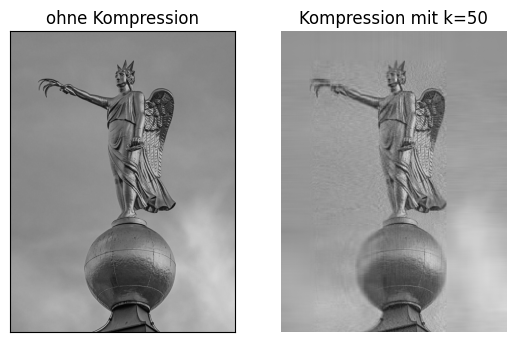

In [38]:

fig = plt.figure()
ax1 = fig.add_subplot(1,2,1)
ax1.imshow(A,cmap='gray')
ax1.set_title('ohne Kompression')
ax1.axes.get_xaxis().set_visible(False)
ax1.axes.get_yaxis().set_visible(False)

ax2 = fig.add_subplot(1,2,2)
ax2.imshow(A_komp,cmap='gray')
ax2.set_title("Kompression mit k="+str(k))
plt.axis('off')
plt.show()

In [39]:
img_komp = Image.fromarray(A_komp)
img_komp.show()
img.show()